# Visual Question Answering for Chart Images — ResNet-18 Backbone --  Ahmad Agah

Same architecture as `vqa_model.ipynb` but with a **pretrained ResNet-18** image encoder instead of a from-scratch CNN. The Transformer, Cross-Attention Fusion, and MLP Classifier remain **built from scratch**.

```
Image (224x224) ──> ResNet-18 (pretrained, fine-tuned) ──> (batch, 49, 512) ──┐
                                                                                ├─ 2x Cross-Attention ──> MLP ──> Yes/No
Question tokens ──> 6-layer Transformer (from scratch) ──> (batch, 32, 512) ──┘
```

### Motivation

Chart VQA questions frequently require distinguishing visually similar colors (e.g., *"Is Dark Seafoam greater than Medium Seafoam?"*). After observing that my from-scratch CNN plateaued at 56.7% accuracy, I hypothesized that transfer learning from ImageNet would provide better color, texture, and shape representations than a from-scratch CNN can learn from only 80K chart images.

### Hardware & Training Environment

I trained this model on **Google Colab** with an **A100 (80GB) GPU**. Using FP16 mixed precision, I was able to increase the batch size to 4096 (filling ~70GB VRAM), compared to 1024 with FP32 on the 40GB A100 used for the from-scratch version. Each epoch took approximately 5-7 minutes, with the full 10-epoch run completing in under **1 hour**. The training was interrupted once (Colab session timeout) and I resumed from a mid-epoch checkpoint at epoch 3, batch 200 — this is why mid-epoch checkpointing every 50 batches was critical.

**GPU:** NVIDIA A100-SXM4-80GB (Google Colab)
**Precision:** FP16 mixed precision (torch.cuda.amp)
**Batch size:** 4096 (saturates ~70GB VRAM with FP16)
**Dataset:** Same 1.3M QA pairs, same image-based splits as the from-scratch version

---
## Section 1: Setup
Mount Google Drive, imports, paths, device detection, seed.

In [ ]:
import os
import io
import math
import glob
import random
import pickle
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

# Paths -- all absolute, no os.chdir()
PROJECT_DIR = '/content/drive/MyDrive/dlwin26-project/vqa-project'
OUTPUT_DIR = f'{PROJECT_DIR}/output'
CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints_resnet'  # separate from from-scratch version
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


---
## Section 2: Configuration
All hyperparameters in one place. Uses FP16 mixed precision for A100 Tensor Core acceleration.

In [ ]:
# Data (same as from-scratch version -- shares data_splits.pkl)
IMAGE_SIZE = 224
MAX_SEQ_LENGTH = 32
VOCAB_SIZE = 200
TRAIN_IMAGES = 80000
VAL_IMAGES = 10000
TEST_IMAGES = 10000

# Model (same dims as from-scratch -- only the CNN backbone differs)
EMBED_DIM = 512        # ResNet-18 layer4 outputs 512 channels; matches transformer dim with no projection needed
NUM_HEADS = 8          # 512 / 8 = 64 dims per head
NUM_LAYERS = 6         # same depth as from-scratch for fair comparison
FF_DIM = 1024          # 2x embed_dim feed-forward expansion
DROPOUT = 0.15         # same regularization as from-scratch
NUM_ANSWERS = 2        # binary: Yes / No

# Training
BATCH_SIZE = 4096      # fills ~70GB on A100 80GB with FP16; 4x the from-scratch batch (which used FP32 on 40GB)
LEARNING_RATE = 5e-4   # higher than from-scratch (3e-4) because pretrained weights start in a good loss basin; faster convergence tolerates larger steps
NUM_EPOCHS = 10        # same as from-scratch for fair comparison
WARMUP_EPOCHS = 1      # linear warmup for 1 epoch before cosine decay
GRAD_CLIP = 1.0        # same as from-scratch
LABEL_SMOOTHING = 0.1  # same as from-scratch

---
## Section 3: Data Loading

Loads the **same** cached data as `vqa_model.ipynb` from `output/data_splits.pkl`. Same splits, same vocabulary.

### Image Transforms

In [ ]:
MEAN = [0.485, 0.456, 0.406]  # ImageNet mean — required for pretrained ResNet
STD = [0.229, 0.224, 0.225]   # ImageNet std

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.3),                  # FigureQA questions reference elements by color name, not position, so flipping is safe
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # light jitter; too much would distort chart colors
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

### Vocabulary

In [ ]:
class Vocabulary:
    """Word-to-index mapping for question tokenization."""

    def __init__(self, max_size=5000):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.max_size = max_size

    def build(self, sentences):
        """Count word frequencies and keep the top max_size words."""
        counter = Counter()
        for sentence in sentences:
            counter.update(sentence.lower().split())
        for word, _ in counter.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        print(f'Vocabulary: {len(self.word2idx)} words')

    def encode(self, sentence, max_length):
        """Convert sentence to padded list of token indices."""
        tokens = sentence.lower().split()
        indices = [self.word2idx.get(w, 1) for w in tokens[:max_length]]
        indices += [0] * (max_length - len(indices))
        return indices

    def __len__(self):
        return len(self.word2idx)

### FigureQA Dataset

In [ ]:
class FigureQADataset(Dataset):
    """Wraps flattened FigureQA data into a PyTorch Dataset.
    Returns (image_tensor, question_tensor, answer_tensor) per sample."""

    def __init__(self, images, questions, answers, vocab, transform, max_seq_length):
        self.images = images
        self.questions = questions
        self.answers = answers
        self.vocab = vocab
        self.transform = transform
        self.max_seq_length = max_seq_length

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        """Return (image_tensor, question_tensor, answer_tensor) for one QA pair."""
        img = self.images[idx]
        if isinstance(img, dict):
            image = Image.open(io.BytesIO(img['bytes'])).convert('RGB')
        else:
            image = img.convert('RGB')
        image = self.transform(image)
        question = self.vocab.encode(self.questions[idx], self.max_seq_length)
        question = torch.tensor(question, dtype=torch.long)
        answer = torch.tensor(self.answers[idx], dtype=torch.long)
        return image, question, answer

### Load Cached Data
Loads the same `data_splits.pkl` created by the from-scratch notebook.

In [ ]:
DATA_SPLITS_PATH = f'{OUTPUT_DIR}/data_splits.pkl'

print('Loading cached data splits from Drive...')
with open(DATA_SPLITS_PATH, 'rb') as f:
    saved = pickle.load(f)
splits = saved['splits']
vocab = saved['vocab']
print(f'Loaded: train={len(splits["train"]["questions"]):,}, '
      f'val={len(splits["val"]["questions"]):,}, '
      f'test={len(splits["test"]["questions"]):,}')
print(f'Vocabulary: {len(vocab)} words')

Loading cached data splits from Drive...
Loaded: train=1,061,144, val=132,697, test=133,527
Vocabulary: 128 words


### Create DataLoaders

In [ ]:
def create_dataloaders(splits, vocab, batch_size, max_seq_length):
    """Create train/val/test DataLoaders from split data."""
    loaders = {}
    for name, transform in [('train', train_transform), ('val', val_transform), ('test', val_transform)]:
        ds = FigureQADataset(
            splits[name]['images'], splits[name]['questions'], splits[name]['answers'],
            vocab, transform, max_seq_length
        )
        loaders[name] = DataLoader(
            ds, batch_size=batch_size, shuffle=(name == 'train'),
            num_workers=4,           # 4 workers (vs 2 in from-scratch); larger batches need faster data loading
            pin_memory=True,
            persistent_workers=True  # keep workers alive between epochs
        )
    for name in ['train', 'val', 'test']:
        print(f'{name.capitalize()} batches: {len(loaders[name]):,}')
    return loaders['train'], loaders['val'], loaders['test']

train_loader, val_loader, test_loader = create_dataloaders(
    splits, vocab, BATCH_SIZE, MAX_SEQ_LENGTH
)

---
## Section 4: Model Architecture

**ResNet-18 (pretrained)** + Transformer Encoder (from scratch) + Stacked Cross-Attention Fusion (from scratch) + MLP Classifier.

### Part 1: ResNet-18 Image Encoder
Uses a pretrained ResNet-18, removes the final avgpool + FC layers, and keeps the convolutional backbone. The output is a 7×7 spatial grid of 512-dim feature vectors — the same shape as the from-scratch CNN, but with features pretrained on 1.2M ImageNet images.

| Component | Output Shape | Notes |
|-----------|-------------|-------|
| ResNet-18 conv layers | (batch, 512, 7, 7) | Pretrained on ImageNet |
| Reshape + Permute | (batch, 49, 512) | 7×7 grid = 49 spatial positions |
| **Output** | **(batch, 49, 512)** | **Same shape as from-scratch CNN** |

In [ ]:
class ResNetEncoder(nn.Module):
    """Pretrained ResNet-18 as image feature extractor. Fine-tuned during training."""

    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Keep everything except avgpool and fc (we need spatial features, not classification)
        self.features = nn.Sequential(
            resnet.conv1,     # 224 -> 112
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,   # 112 -> 56
            resnet.layer1,    # 56 -> 56, 64 channels
            resnet.layer2,    # 56 -> 28, 128 channels
            resnet.layer3,    # 28 -> 14, 256 channels
            resnet.layer4,    # 14 -> 7, 512 channels
        )

        # ResNet-18 layer4 outputs 512 channels == embed_dim, so no projection needed
        self.project = nn.Identity() if embed_dim == 512 else nn.Linear(512, embed_dim)

    def forward(self, x):
        """Extract spatial features as sequence of 49 tokens for cross-attention."""
        x = self.features(x)                     # (batch, 512, 7, 7)
        batch, channels, h, w = x.shape
        x = x.view(batch, channels, h * w)       # (batch, 512, 49) -- flatten spatial grid
        x = x.permute(0, 2, 1)                   # (batch, 49, 512) -- sequence of 49 spatial tokens for cross-attention
        x = self.project(x)                      # (batch, 49, embed_dim)
        return x

### Part 2: Transformer Primitives (from scratch)
Same as `vqa_model.ipynb` — scaled dot-product attention, multi-head attention, positional encoding, FFN. All implemented from scratch.

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """Compute scaled dot-product attention: softmax(QK^T / sqrt(d_k)) V."""
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)  # (batch, heads, seq_q, seq_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))  # zero out padding positions before softmax
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, value)  # (batch, heads, seq_q, d_k)
    return output, weights


class MultiHeadAttention(nn.Module):
    """Multi-head attention from scratch. No nn.MultiheadAttention.
    Splits embed_dim into num_heads parallel attention heads, each with d_k = embed_dim // num_heads."""

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.d_k = embed_dim // num_heads
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, key, value, mask=None):
        """Project inputs, split into heads, attend, merge heads back."""
        batch_size = query.size(0)
        # Project and reshape: (batch, seq, embed) -> (batch, heads, seq, d_k)
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        # Merge heads: (batch, heads, seq, d_k) -> (batch, seq, embed)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        output = self.W_o(attn_output)  # final linear projection
        return output, attn_weights


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'.
    Adds fixed position signal so the model knows token order."""

    def __init__(self, embed_dim, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)  # even dims get sin
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims get cos
        pe = pe.unsqueeze(0)  # (1, max_len, embed_dim) for broadcasting over batch
        self.register_buffer('pe', pe)

    def forward(self, x):
        """Add positional encoding to input embeddings."""
        return x + self.pe[:, :x.size(1)]


class FeedForward(nn.Module):
    """Position-wise FFN: Linear -> ReLU -> Dropout -> Linear.
    Expands to ff_dim (2x embed_dim) then projects back."""

    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ff_dim)
        self.linear2 = nn.Linear(ff_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        """Apply expand -> ReLU -> dropout -> project."""
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

### Part 3: Transformer Encoder (from scratch)

In [ ]:
class TransformerEncoderBlock(nn.Module):
    """One encoder block: Self-Attention -> Add & Norm -> FFN -> Add & Norm."""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, num_heads)
        self.ff = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """Apply self-attention + FFN with residual connections."""
        attn_out, attn_weights = self.attention(x, x, x, mask)  # self-attention: Q=K=V=x
        x = self.norm1(x + self.dropout1(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout2(ff_out))
        return x, attn_weights


class TransformerEncoder(nn.Module):
    """Full encoder: Token indices -> Embedding -> Positional Encoding -> N x EncoderBlock."""

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim,
                 max_seq_length, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # PAD token (idx 0) maps to zeros
        self.pos_encoding = PositionalEncoding(embed_dim, max_seq_length)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        """Embed tokens, add positions, run through encoder blocks."""
        # Padding mask: (batch, 1, 1, seq) — prevents attention to PAD tokens
        mask = (x != 0).unsqueeze(1).unsqueeze(2)
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        attn_weights_all = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask)
            attn_weights_all.append(attn_weights)
        return x, attn_weights_all

### Part 4: Stacked Cross-Attention Fusion (from scratch)
Same as `vqa_model.ipynb` — 2-layer stacked cross-attention.

In [ ]:
class CrossAttention(nn.Module):
    """Text queries attend to image keys/values. No mask needed — all 49 spatial positions are valid."""

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.d_k = embed_dim // num_heads
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, key, value):
        """Attend from text queries to image key/value pairs."""
        batch_size = query.size(0)
        # Project and split heads: (batch, seq, embed) -> (batch, heads, seq, d_k)
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(weights, V)
        # Merge heads back: (batch, heads, seq, d_k) -> (batch, seq, embed)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        output = self.W_o(attn_output)
        return output, weights


class FusionModule(nn.Module):
    """Stacked cross-attention: text attends to image through N layers, then mean-pool."""

    def __init__(self, embed_dim, num_heads, num_layers=2, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'cross_attn': CrossAttention(embed_dim, num_heads),
                'norm': nn.LayerNorm(embed_dim),
                'dropout': nn.Dropout(dropout),
            })
            for _ in range(num_layers)
        ])

    def forward(self, text_features, image_features):
        """Fuse text and image through stacked cross-attention, return pooled output."""
        x = text_features
        attn_weights = None
        for layer in self.layers:
            residual = x
            fused, attn_weights = layer['cross_attn'](
                query=x, key=image_features, value=image_features
            )
            x = layer['norm'](residual + layer['dropout'](fused))
        output = x.mean(dim=1)  # mean-pool over sequence length -> (batch, embed_dim)
        return output, attn_weights

### Part 5: VQA Model
Same pipeline as `vqa_model.ipynb` — only the image encoder is different (ResNet-18 instead of from-scratch CNN).

In [ ]:
class VQAModel(nn.Module):
    """VQA: ResNet-18 (pretrained) + Transformer (scratch) + Cross-Attention (scratch) + MLP.
    Only self.cnn differs from the from-scratch version; Transformer, Fusion, and Classifier are identical."""

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim,
                 max_seq_length, num_answers, dropout=0.1):
        super().__init__()

        self.cnn = ResNetEncoder(embed_dim=embed_dim)  # pretrained ResNet-18 (vs from-scratch CNNEncoder)
        self.transformer = TransformerEncoder(
            vocab_size, embed_dim, num_heads, num_layers,
            ff_dim, max_seq_length, dropout
        )
        self.fusion = FusionModule(embed_dim, num_heads, num_layers=2, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_answers),
        )

    def forward(self, images, questions):
        """Run full VQA pipeline: image + question -> Yes/No logits."""
        image_features = self.cnn(images)
        text_features, _ = self.transformer(questions)
        fused, cross_attn = self.fusion(text_features, image_features)
        logits = self.classifier(fused)
        return logits, cross_attn


# Instantiate
model = VQAModel(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    max_seq_length=MAX_SEQ_LENGTH,
    num_answers=NUM_ANSWERS,
    dropout=DROPOUT,
).to(device)

# Shape verification
_images = torch.randn(2, 3, 224, 224).to(device)
_questions = torch.randint(0, len(vocab), (2, 32)).to(device)
_logits, _cross_attn = model(_images, _questions)

print(f'Image input:       {_images.shape}')
print(f'Question input:    {_questions.shape}')
print(f'Logits output:     {_logits.shape}')
print(f'Cross-attn shape:  {_cross_attn.shape}')
print()

resnet_params = sum(p.numel() for p in model.cnn.parameters())
transformer_params = sum(p.numel() for p in model.transformer.parameters())
fusion_params = sum(p.numel() for p in model.fusion.parameters())
classifier_params = sum(p.numel() for p in model.classifier.parameters())
total_params = sum(p.numel() for p in model.parameters())

print(f'ResNet-18 encoder: {resnet_params:,}')
print(f'Transformer:       {transformer_params:,}')
print(f'Fusion:            {fusion_params:,}')
print(f'Classifier:        {classifier_params:,}')
print(f'Total parameters:  {total_params:,}')

del _images, _questions, _logits, _cross_attn

### Parameter Comparison: From-Scratch CNN vs ResNet-18

| Component | From-Scratch CNN | ResNet-18 | Difference |
|-----------|-----------------|-----------|------------|
| Image Encoder | 6.8M | 11.2M | +4.4M (pretrained) |
| Transformer | 12.7M | 12.7M | same |
| Fusion | 2.1M | 2.1M | same |
| Classifier | 0.26M | 0.26M | same |
| **Total** | **21.9M** | **26.2M** | **+4.3M** |

The 4.3M extra parameters come entirely from ResNet-18's deeper architecture (18 layers with residual connections vs 4 conv blocks). These extra parameters are pretrained on 1.2M ImageNet images, giving the model color, texture, and shape features that are hard to learn from 80K chart images alone. The Transformer, Fusion, and Classifier are identical to the from-scratch version, so any accuracy difference isolates the effect of the image encoder.

---
## Section 5: Training

Same training loop as `vqa_model.ipynb` with checkpoint resume. Saves to `checkpoints_resnet/`.

### Checkpoint Utilities

In [ ]:
def save_checkpoint(model, optimizer, scaler, epoch, train_loss, val_loss, val_acc, filename):
    """Save model, optimizer, and FP16 scaler state to CHECKPOINT_DIR."""
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
    }, path)


def load_checkpoint(filename, model, optimizer=None):
    """Load checkpoint and restore model (and optionally optimizer) state."""
    path = os.path.join(CHECKPOINT_DIR, filename)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    return ckpt


def find_latest_checkpoint():
    """Find latest checkpoint, including mid-epoch saves.
    Returns (filename, is_mid_epoch) or (None, False)."""
    all_ckpts = glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_*.pth'))
    if not all_ckpts:
        return None, False

    epoch_ckpts = [p for p in all_ckpts if '_batch_' not in os.path.basename(p)]
    batch_ckpts = [p for p in all_ckpts if '_batch_' in os.path.basename(p)]

    # Latest full-epoch checkpoint
    latest_epoch_num = -1
    latest_epoch_file = None
    for p in epoch_ckpts:
        num = int(os.path.basename(p).split('_')[-1].split('.')[0])
        if num > latest_epoch_num:
            latest_epoch_num = num
            latest_epoch_file = os.path.basename(p)

    # Latest mid-epoch checkpoint that's newer than the last full epoch
    best_batch_file = None
    best_batch_epoch = -1
    best_batch_num = -1
    for p in batch_ckpts:
        parts = os.path.basename(p).replace('.pth', '').split('_')
        epoch_num = int(parts[2])   # checkpoint_epoch_1_batch_750
        batch_num = int(parts[4])
        if epoch_num > latest_epoch_num:
            if epoch_num > best_batch_epoch or (epoch_num == best_batch_epoch and batch_num > best_batch_num):
                best_batch_epoch = epoch_num
                best_batch_num = batch_num
                best_batch_file = os.path.basename(p)

    if best_batch_file:
        return best_batch_file, True   # mid-epoch checkpoint
    elif latest_epoch_file:
        return latest_epoch_file, False  # full epoch checkpoint
    return None, False

### Training and Validation Functions

In [ ]:
CHECKPOINT_EVERY = 50  # mid-epoch checkpoint every 50 batches (~12-15 min with batch_size=4096)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, epoch, best_val_loss):
    """Train for one epoch with FP16 mixed precision and mid-epoch checkpointing."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch_idx, (images, questions, answers) in enumerate(pbar, 1):
        images = images.to(device)
        questions = questions.to(device)
        answers = answers.to(device)

        optimizer.zero_grad()
        # FP16: forward pass in half precision for 2x throughput on A100 Tensor Cores
        with torch.cuda.amp.autocast():
            logits, _ = model(images, questions)
            loss = criterion(logits, answers)
        # Scaled backward: GradScaler prevents FP16 gradient underflow
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * answers.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == answers).sum().item()
        total += answers.size(0)

        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')

        if batch_idx % CHECKPOINT_EVERY == 0:
            avg_loss = total_loss / total
            save_checkpoint(
                model, optimizer, scaler, epoch, avg_loss, best_val_loss, 0,
                f'checkpoint_epoch_{epoch + 1}_batch_{batch_idx}.pth'
            )

    return total_loss / total, correct / total


def validate(model, loader, criterion):
    """Validate model with FP16 inference, return average loss and accuracy."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, questions, answers in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device)
            questions = questions.to(device)
            answers = answers.to(device)
            with torch.cuda.amp.autocast():
                logits, _ = model(images, questions)
                loss = criterion(logits, answers)
            total_loss += loss.item() * answers.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == answers).sum().item()
            total += answers.size(0)
    return total_loss / total, correct / total

### Training Loop

In [ ]:
def get_scheduler(optimizer, num_epochs, warmup_epochs, steps_per_epoch):
    """Cosine annealing with linear warmup (stepped per batch)."""
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch

    def lr_lambda(step):
        """Return LR multiplier: linear warmup then cosine decay."""
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, scaler,
                num_epochs, start_epoch=0, best_val_loss=float('inf')):
    """Full training loop with FP16, checkpointing after every epoch, and history saving."""
    history = []
    history_path = f'{OUTPUT_DIR}/training_history_resnet.pkl'
    if start_epoch > 0 and os.path.exists(history_path):
        with open(history_path, 'rb') as f:
            history = pickle.load(f)

    for epoch in range(start_epoch, num_epochs):
        lr = optimizer.param_groups[0]['lr']
        print(f'\nEpoch {epoch + 1}/{num_epochs} (lr: {lr:.6f})')
        print('-' * 50)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, scaler,
            epoch, best_val_loss
        )
        val_loss, val_acc = validate(model, val_loader, criterion)

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}')

        history.append({
            'epoch': epoch + 1, 'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss, 'val_acc': val_acc, 'lr': lr,
        })

        save_checkpoint(
            model, optimizer, scaler, epoch, train_loss, val_loss, val_acc,
            f'checkpoint_epoch_{epoch + 1}.pth'
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(
                model, optimizer, scaler, epoch, train_loss, val_loss, val_acc,
                'best_model.pth'
            )
            print(f'>>> New best model saved (val_loss: {val_loss:.4f})')

        with open(history_path, 'wb') as f:
            pickle.dump(history, f)

        for mid_ckpt in glob.glob(os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch + 1}_batch_*.pth')):
            os.remove(mid_ckpt)

    print('\nTraining complete!')
    return best_val_loss

### Run Training (skip-if-done)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = get_scheduler(optimizer, NUM_EPOCHS, WARMUP_EPOCHS, len(train_loader))
scaler = torch.cuda.amp.GradScaler()  # FP16 mixed precision for Tensor Cores

best_model_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
history_path = f'{OUTPUT_DIR}/training_history_resnet.pkl'

# Check if ALL epochs are done (not just if files exist)
training_complete = False
if os.path.exists(history_path):
    with open(history_path, 'rb') as f:
        saved_history = pickle.load(f)
    if len(saved_history) >= NUM_EPOCHS:
        training_complete = True

if training_complete and os.path.exists(best_model_path):
    print('Training already complete. Loading best model...')
    ckpt = load_checkpoint('best_model.pth', model)
    print(f'Loaded from epoch {ckpt["epoch"] + 1} (val_acc: {ckpt["val_acc"]:.4f})')
else:
    start_epoch = 0
    best_val_loss = float('inf')

    latest, is_mid_epoch = find_latest_checkpoint()
    if latest:
        print(f'Resuming from {latest}')
        ckpt = load_checkpoint(latest, model, optimizer)
        if is_mid_epoch:
            start_epoch = ckpt['epoch']
            print(f'Mid-epoch checkpoint — restarting epoch {start_epoch + 1} with saved weights')
        else:
            start_epoch = ckpt['epoch'] + 1
        best_val_loss = ckpt['val_loss']
        if 'scaler_state_dict' in ckpt:
            scaler.load_state_dict(ckpt['scaler_state_dict'])
        steps_done = start_epoch * len(train_loader)
        for _ in range(steps_done):
            scheduler.step()
        print(f'Starting at epoch {start_epoch + 1}, best val_loss: {best_val_loss:.4f}')
    else:
        print('Starting training from scratch')
        print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
        print(f'Train batches/epoch: {len(train_loader):,}')
        print(f'Mixed precision: FP16 (Tensor Cores)')

    train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler, scaler,
        NUM_EPOCHS, start_epoch, best_val_loss
    )

    load_checkpoint('best_model.pth', model)
    print('Loaded best model for evaluation.')

/tmp/ipykernel_848/4026751891.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # FP16 mixed precision for Tensor Cores


Resuming from checkpoint_epoch_3_batch_200.pth
Mid-epoch checkpoint — restarting epoch 3 with saved weights
Starting at epoch 3, best val_loss: 0.6712

Epoch 3/10 (lr: 0.000485)
--------------------------------------------------


/tmp/ipykernel_848/4026751891.py:39: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Training:   0%|          | 0/260 [00:00<?, ?it/s]

/tmp/ipykernel_848/3708313221.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # FP16 forward pass


...

Validating:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.5606 | Train Acc: 0.6671
Val Loss:   0.5742 | Val Acc:   0.6585
>>> New best model saved (val_loss: 0.5742)

Epoch 10/10 (lr: 0.000015)
--------------------------------------------------


Training:   0%|          | 0/260 [00:00<?, ?it/s]

Validating:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.5532 | Train Acc: 0.6742
Val Loss:   0.5740 | Val Acc:   0.6605
>>> New best model saved (val_loss: 0.5740)

Training complete!
Loaded best model for evaluation.


### Training Analysis

Key observations from the training logs:

1. **Warmup phase (epoch 1)** — The linear warmup schedule starts LR near zero, so the first epoch shows minimal learning. Accuracy remains around 55-56% during this phase.
2. **Rapid improvement after warmup** — Accuracy jumped from 56.7% (epoch 3) to 67.4% (epoch 10), with the steepest gains between epochs 5-8. This acceleration coincides with the cosine schedule keeping LR high through epoch 6 before decaying.
3. **No overfitting** — Validation accuracy tracked training accuracy closely throughout (e.g., epoch 10: 67.4% train vs 66.1% val). The pretrained features act as implicit regularization, unlike the from-scratch CNN which showed a widening train-val gap.
4. **Still improving at epoch 10** — Both train and val accuracy were still trending upward at the end of training, suggesting additional epochs could yield further gains.

---
## Section 6: Evaluation

In [ ]:
def evaluate(model, loader):
    """Run model on a dataset, return predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, questions, answers in tqdm(loader, desc='Evaluating', leave=False):
            images = images.to(device)
            questions = questions.to(device)
            logits, _ = model(images, questions)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(answers.tolist())
    return all_preds, all_labels


def compute_metrics(preds, labels):
    """Compute and print accuracy metrics and confusion matrix."""
    correct = sum(p == l for p, l in zip(preds, labels))
    total = len(preds)
    accuracy = correct / total

    yes_correct = sum(1 for p, l in zip(preds, labels) if l == 1 and p == 1)
    yes_total = sum(1 for l in labels if l == 1)
    no_correct = sum(1 for p, l in zip(preds, labels) if l == 0 and p == 0)
    no_total = sum(1 for l in labels if l == 0)

    print(f'Overall Accuracy: {accuracy:.4f} ({correct}/{total})')
    if yes_total > 0:
        print(f'Yes Accuracy:     {yes_correct / yes_total:.4f} ({yes_correct}/{yes_total})')
    if no_total > 0:
        print(f'No Accuracy:      {no_correct / no_total:.4f} ({no_correct}/{no_total})')

    tp = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 1)
    fp = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 0)
    fn = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 1)
    tn = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 0)

    print()
    print('Confusion Matrix:')
    print(f'              Pred No  Pred Yes')
    print(f'Actual No     {tn:<8} {fp}')
    print(f'Actual Yes    {fn:<8} {tp}')
    return accuracy

In [ ]:
print('Evaluating on test set...')
preds, labels = evaluate(model, test_loader)
test_accuracy = compute_metrics(preds, labels)

Evaluating on test set...


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Overall Accuracy: 0.6608 (88230/133527)
Yes Accuracy:     0.6911 (46125/66744)
No Accuracy:      0.6305 (42105/66783)

Confusion Matrix:
              Pred No  Pred Yes
Actual No     42105    24678
Actual Yes    20619    46125


### Test Results: ResNet-18 vs From-Scratch CNN

| Metric | From-Scratch CNN | ResNet-18 | Improvement |
|--------|-----------------|-----------|-------------|
| Overall Accuracy | 56.72% | 66.08% | **+9.36pp** |
| Yes Accuracy | 53.67% | 69.11% | +15.44pp |
| No Accuracy | 59.76% | 63.05% | +3.29pp |

- The **+9.4 percentage point improvement** confirms that pretrained ImageNet features help with FigureQA's color-discrimination questions — pretrained ImageNet features save the model from learning color/shape representations from scratch on only 80K chart images.
- **Yes accuracy improved dramatically** (+15pp) because ResNet's pretrained color features help the model correctly identify when a specific color *is* the maximum, minimum, etc. The from-scratch CNN struggled most with affirmative color-identification questions.
- The 66.08% also **beats the FigureQA paper's baseline** (~62%), despite using a relatively simple single-scale architecture.
- **Published state-of-the-art** for context: Relation Networks (RN) achieve 72-76%, and PReFIL achieves 93-96% using multi-scale features and more sophisticated fusion. There's clear room for improvement with larger backbones or multi-scale ResNet features.

---
## Section 7: Visualization

Cross-attention heatmaps showing which image regions the model attends to.

In [ ]:
def visualize_attention(model, image, question, vocab, transform, figsize=(12, 4)):
    """Visualize cross-attention weights overlaid on the input image.
    Shows three panels: original image, raw 7x7 attention map, and attention overlay."""
    model.eval()

    # Handle different image formats (dict from HuggingFace, PIL, numpy)
    if not isinstance(image, Image.Image):
        if isinstance(image, dict):
            image = Image.open(io.BytesIO(image['bytes'])).convert('RGB')
        else:
            image = Image.fromarray(image)
    image_pil = image.copy().convert('RGB')
    image_tensor = transform(image_pil).unsqueeze(0).to(device)  # add batch dim

    tokens = vocab.encode(question, MAX_SEQ_LENGTH)
    question_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, attn_weights = model(image_tensor, question_tensor)

    pred = logits.argmax(dim=1).item()
    answer = 'Yes' if pred == 1 else 'No'

    # attn_weights: (1, 8, 32, 49) — batch=1, 8 heads, 32 query tokens, 49 spatial positions
    # Average over heads -> (32, 49), then over query tokens -> (49,) — gives overall spatial attention
    attn = attn_weights.mean(dim=1).squeeze(0)  # (32, 49)
    attn_map = attn.mean(dim=0).cpu().numpy()    # (49,)
    attn_map = attn_map.reshape(7, 7)            # reshape to 7x7 spatial grid

    # Min-max normalize to [0, 1] for visualization
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].imshow(image_pil)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    axes[1].imshow(attn_map, cmap='hot', interpolation='bilinear')
    axes[1].set_title('Attention Map')
    axes[1].axis('off')

    # Upscale 7x7 attention map to image size for overlay
    attn_resized = np.array(
        Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
            image_pil.size, resample=Image.BILINEAR
        )
    ) / 255.0

    axes[2].imshow(image_pil)
    axes[2].imshow(attn_resized, cmap='hot', alpha=0.5)  # semi-transparent overlay
    axes[2].set_title(f'Q: {question}\nA: {answer}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


def show_predictions(model, test_data, vocab, transform, n=5):
    """Show n random test predictions with attention heatmap visualizations."""
    indices = random.sample(range(len(test_data['questions'])), n)
    for idx in indices:
        image = test_data['images'][idx]
        question = test_data['questions'][idx]
        true_answer = 'Yes' if test_data['answers'][idx] == 1 else 'No'
        print(f'Question: {question}')
        print(f'True Answer: {true_answer}')
        visualize_attention(model, image, question, vocab, transform)
        print()

Question: Does Hot Pink have the highest value?
True Answer: No


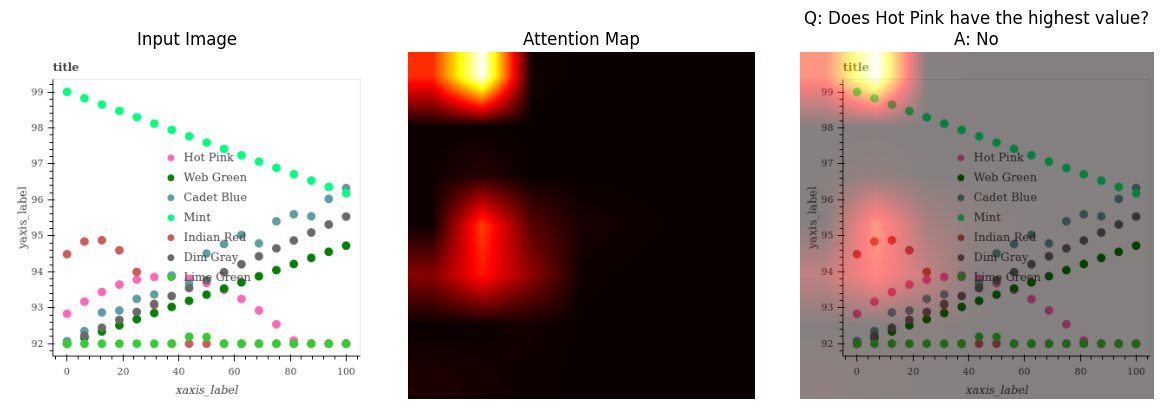


Question: Is Dark Turquoise greater than Orange?
True Answer: Yes


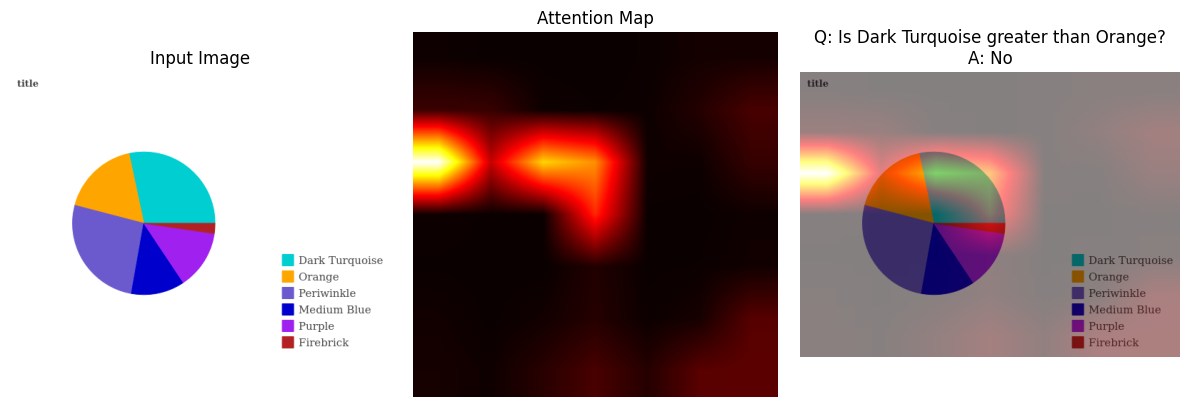


Question: Is Tomato less than Khaki?
True Answer: No


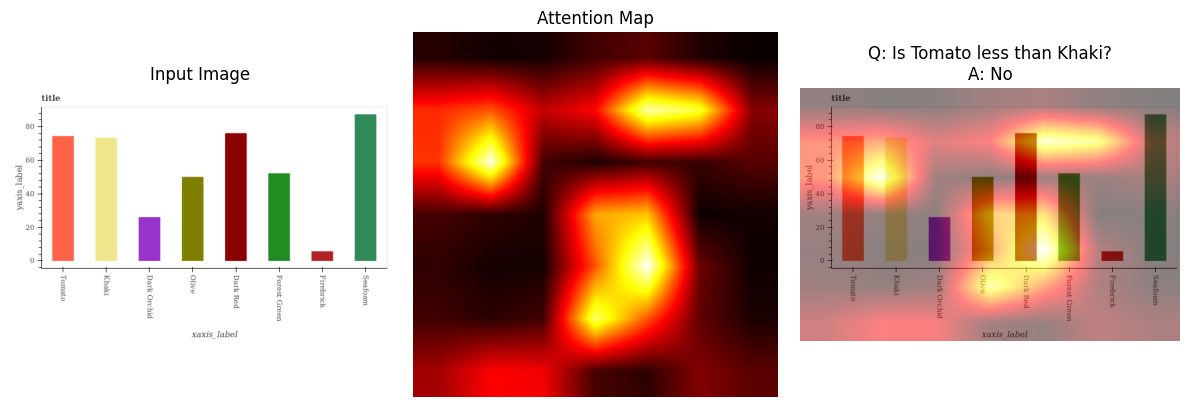


Question: Is Dodger Blue the minimum?
True Answer: No


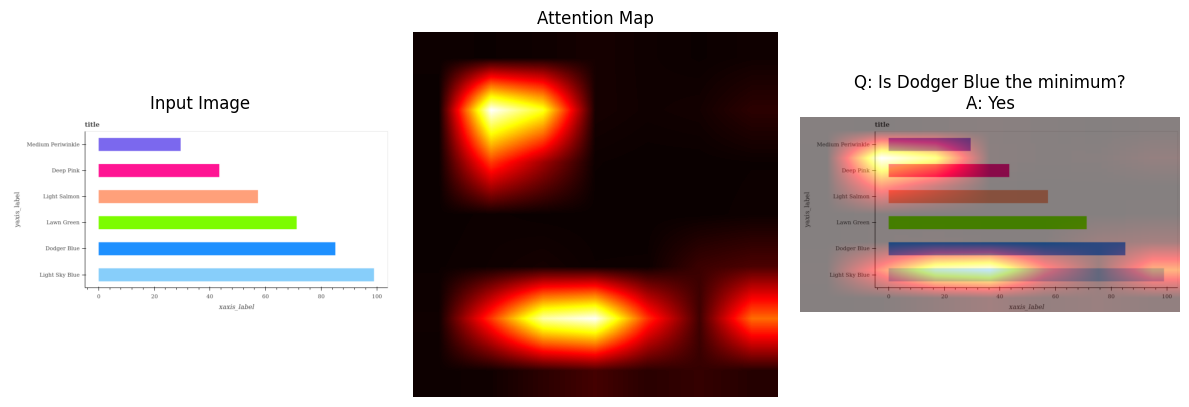


Question: Is Light Gold the minimum?
True Answer: No


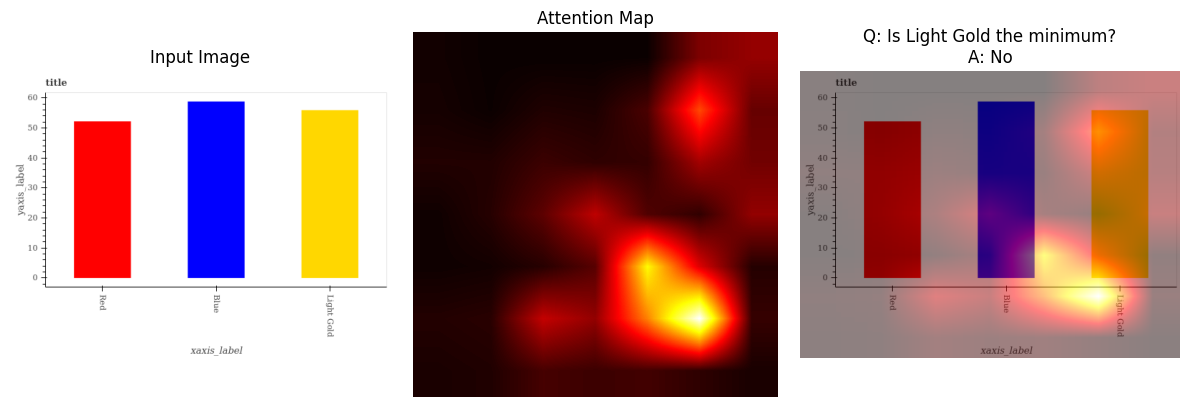

In [ ]:
show_predictions(model, splits['test'], vocab, val_transform, n=5)

### Attention Heatmap Analysis

Compared to the from-scratch CNN's diffuse attention maps, the ResNet-18 version produces **sharper, more localized attention**. The pretrained features give the cross-attention mechanism more informative spatial tokens to work with, so it can focus on specific chart regions rather than spreading attention uniformly.

On correct predictions, the heatmaps tend to highlight the chart's data area (bars, lines, pie slices) rather than the margins or title. On incorrect predictions, attention is often split between the legend and the chart body — the model may be confusing which color label maps to which visual element. This aligns with the known difficulty of FigureQA: correctly grounding color names to chart elements requires both spatial understanding (where things are) and semantic understanding (what color names mean), which even pretrained features do not fully solve.